In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
df = pd.read_csv('Social_Network_Ads.csv')


In [51]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


C:\Users\harsh\AppData\Local\Temp\ipykernel_15568\2438558368.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['Age'], shade=True)


<Axes: xlabel='Age', ylabel='Density'>

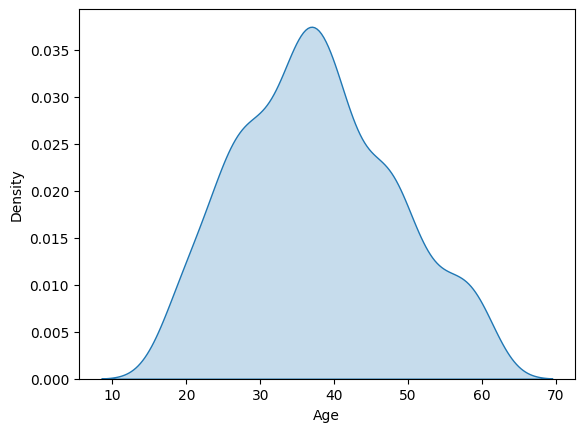

In [41]:
sns.kdeplot(df['Age'], shade=True)

C:\Users\harsh\AppData\Local\Temp\ipykernel_15568\461661825.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['EstimatedSalary'], shade=True, color='orange')


<Axes: xlabel='EstimatedSalary', ylabel='Density'>

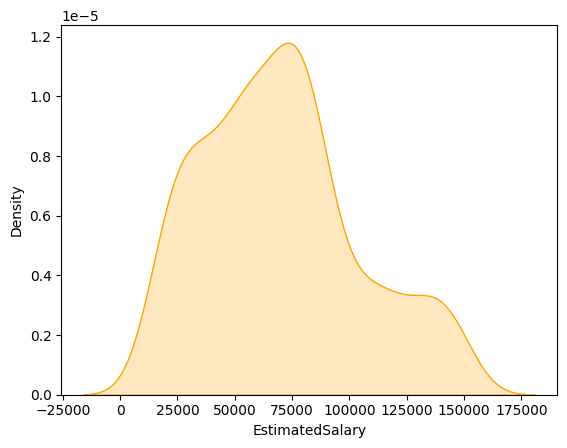

In [42]:
sns.kdeplot(df['EstimatedSalary'], shade=True, color='orange')

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

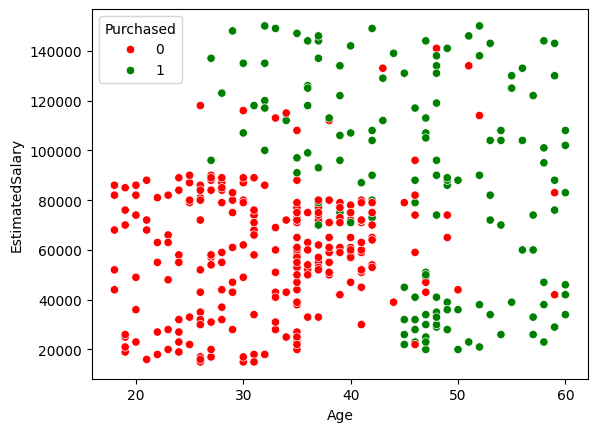

In [43]:
color_dict = {0: 'red', 1: 'green'}
sns.scatterplot(
    x = df['Age'], 
    y = df['EstimatedSalary'], 
    hue=df['Purchased'], 
    palette=color_dict
)

In [59]:
df['Gender'] = df['Gender'].map({
    'Male' : 1,
    'Female' : 0
})

In [60]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1), df['Purchased'], test_size=0.2, random_state=42)

In [61]:
X_train.shape, X_test.shape

((320, 4), (80, 4))

In [62]:
df.dtypes

User ID              int64
Gender             float64
Age                  int64
EstimatedSalary      int64
Purchased            int64
dtype: object

In [63]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler()

sc.fit(X_train)

c:\Users\harsh\Desktop\Saloni\ml\.venv\lib\site-packages\sklearn\utils\_array_api.py:686: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
c:\Users\harsh\Desktop\Saloni\ml\.venv\lib\site-packages\sklearn\utils\_array_api.py:706: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


,feature_range,"(0, ...)"
,copy,True
,clip,False


In [64]:
X_train_Scaled = sc.transform(X_train)
X_test_Scaled = sc.transform(X_test)

In [66]:
X_train_Scaled = pd.DataFrame(X_train_Scaled, columns=X_train.columns)
X_test_Scaled = pd.DataFrame(X_test_Scaled, columns=X_test.columns)

In [67]:
np.round(X_train.describe(),1)

,User ID,Gender,Age,EstimatedSalary
count,320.0,0.0,320.0,320.0
mean,15689066.4,NaN,37.9,70281.2
std,71974.3,NaN,10.2,34430.6
min,15569641.0,NaN,18.0,15000.0
25%,15622771.0,NaN,30.0,43000.0
50%,15689969.5,NaN,37.0,71000.0
75%,15747470.0,NaN,45.0,88000.0
max,15815236.0,NaN,60.0,150000.0


In [68]:
np.round(X_train_Scaled.describe(), 1)

,User ID,Gender,Age,EstimatedSalary
count,320.0,0.0,320.0,320.0
mean,0.5,NaN,0.5,0.4
std,0.3,NaN,0.2,0.3
min,0.0,NaN,0.0,0.0
25%,0.2,NaN,0.3,0.2
50%,0.5,NaN,0.5,0.4
75%,0.7,NaN,0.6,0.5
max,1.0,NaN,1.0,1.0


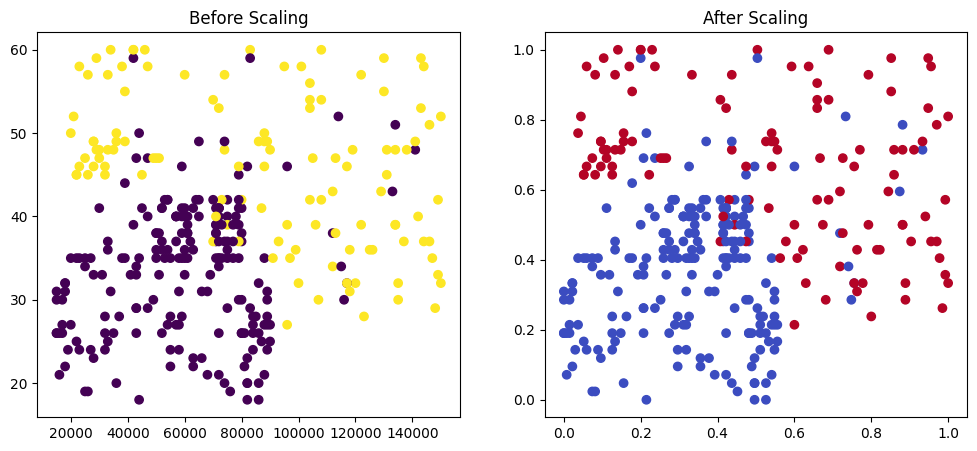

In [ ]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.set_title("Before Scaling")
ax1.scatter(X_train['EstimatedSalary'], X_train['Age'], c=y_train)

ax2.set_title("After Scaling")
ax2.scatter(X_train_Scaled['EstimatedSalary'], X_train_Scaled['Age'], c=y_train, cmap='coolwarm')

# c=y_train colors points according to target classes.
# cmap='coolwarm' assigns different colors to each class,
# making class separation easier to visualize.

C:\Users\harsh\AppData\Local\Temp\ipykernel_15568\4286559635.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(X_train['EstimatedSalary'], shade=True, ax=ax1)
C:\Users\harsh\AppData\Local\Temp\ipykernel_15568\4286559635.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(X_train['Age'], shade=True, ax=ax1)


<Axes: title={'center': 'After Scaling'}, xlabel='EstimatedSalary', ylabel='Density'>

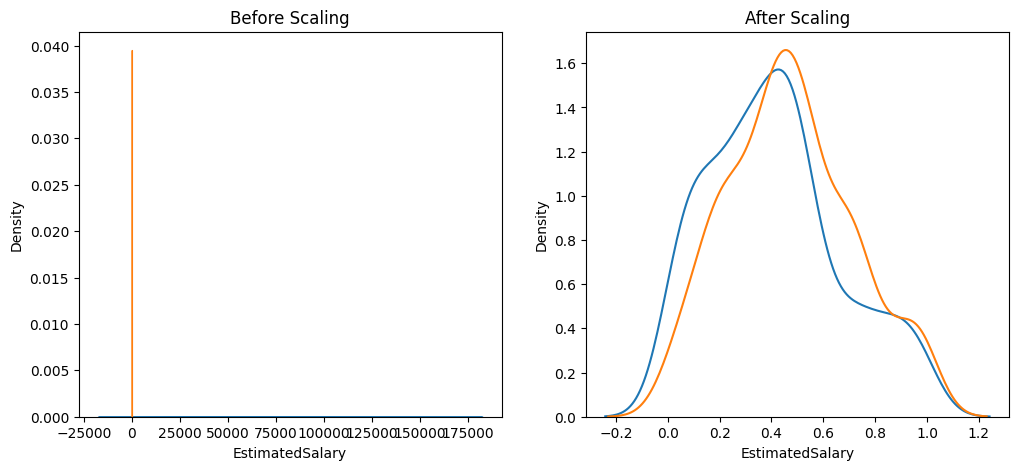

In [79]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.set_title("Before Scaling")
sns.kdeplot(X_train['EstimatedSalary'], shade=True, ax=ax1)
sns.kdeplot(X_train['Age'], shade=True, ax=ax1)

ax2.set_title("After Scaling")
sns.kdeplot(X_train_Scaled['EstimatedSalary'], ax=ax2)
sns.kdeplot(X_train_Scaled['Age'], ax=ax2)

C:\Users\harsh\AppData\Local\Temp\ipykernel_15568\1994838901.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(X_train['EstimatedSalary'], shade=True, ax=ax1)


<Axes: title={'center': 'EstimatedSalary After Scaling'}, xlabel='EstimatedSalary', ylabel='Density'>

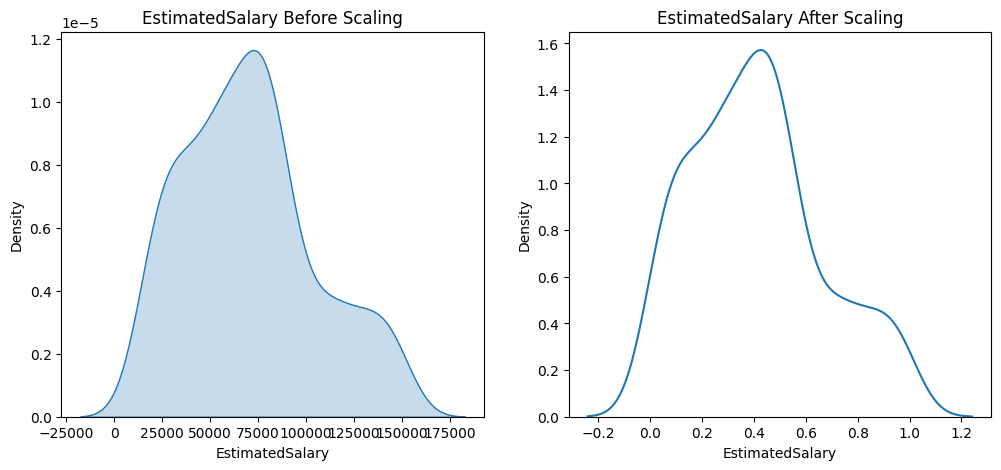

In [80]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.set_title("EstimatedSalary Before Scaling")
sns.kdeplot(X_train['EstimatedSalary'], shade=True, ax=ax1)

ax2.set_title("EstimatedSalary After Scaling")
sns.kdeplot(X_train_Scaled['EstimatedSalary'], ax=ax2)

C:\Users\harsh\AppData\Local\Temp\ipykernel_15568\2245691039.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(X_train_Scaled['Age'], ax=ax2, shade=True,)


<Axes: title={'center': 'Age After Scaling'}, xlabel='Age', ylabel='Density'>

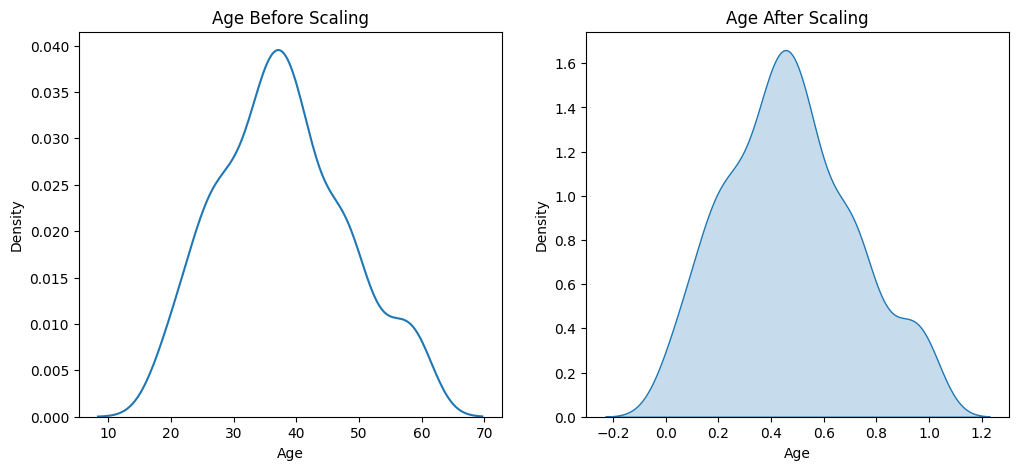

In [82]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.set_title("Age Before Scaling")
sns.kdeplot(X_train['Age'], ax=ax1)

ax2.set_title("Age After Scaling")
sns.kdeplot(X_train_Scaled['Age'], ax=ax2, shade=True,)